# Real dataset: M. tuberculosis strains vs. anti-tuberculosis drugs

### Highlights: 

- The 14 common drugs used to treat tuberculosis (结核病), as mentioned in [F. Coll, J. Phelan, G. A. Hill-Cawthorne, et al., “Genome-wide analysis of multi- and extensively drug-resistant mycobacterium tuberculosis,” Nat. Genet. 50 (2), 307–316 (2018).](https://www.nature.com/articles/s41588-017-0029-0): 

    Isoniazid (INH), 

    Rifampicin (RIF), 

    Ethionamide (ETH), 

    Pyrazinamide (PZA), 

    Ethambutol (EMB), 

    Streptomycin (STM), 

    Amikacin (AMK), 

    Capreomycin (CAP), 

    Kanamycin (KAN), 

    Ciprofloxacin (CIP), 

    Ofloxacin (OFL), 

    Moxifloxacin (MOX), 

    Cycloserine (CYS), 

    Para-aminosalicylic acid (PAS).

    The last two is not the same as the dataset used in SGIMC. Instead, they used Prothionamide. 

- We still focused on the same 13 drugs as used in SGIMC:

    Isoniazid (INH)

    Ethambutol (EMB)

    Rifampicin (RIF)

    Pyrazinamide (PZA)

    Streptomycin (STM)

    Ofloxacin (OFL)

    Capreomycin (CAP)

    Amikacin (AMK)

    Moxifloxacin (MOX)

    Kanamycin (KAN)

    Prothionamide (PTO)

    Ciprofloxacin (CIP)

    Ethionamide (ETH)


### Remarks: 

- [PubChem](https://pubchem.ncbi.nlm.nih.gov/docs/glossary#section=SMILES) announced: The former "Canonical SMILES" property in our compound records has been replaced by a newly-named "Connectivity SMILES" property, to avoid confusion with historical terms and hopefully make the intention of this SMILES variant more clear: that it contains only the connectivity layer of the compound, and not stereochemistry or isotopes (similar to the first block of the InChI key).

### Workflow details:

1. Prepare drug chemical property as side information for 13 drugs. 

    - More detailes: we extracted 34 common functional groups using SMART codes, then we excluded those features being all 0's. 

2. Prepare M. Tuberculosis strains and drug resistance association matrix:
    
    - We got 622 different genome records after removing duplicated drug resistence patterns, otherwise the full list has 18132 records. 

    - We then mapped the genome information with strains information, reached 7932 unique strains, with 6949 strains tested with all 13 drugs. 

    - We further removed strains in the next step when certain strains' genome ID cannot fetch valid genome data from NCBI for mutation mapping. 

3. Prepare M. Tuberculosis strains gene mutation information. 

    - We choose SNP as our gene mutation information with minimum coverage threshould at 10. 

    

---

### 1. Drug side information

In [ ]:
from rdkit import Chem
from rdkit.Chem import inchi
import pandas as pd
import requests
from time import sleep
import os

save_dir = (
    "/Users/sijianfan/Documents/projects/BiSSGL/datasets/realAnalysis/tuberculosis"
)
os.makedirs(f"{save_dir}", exist_ok=True)

In [4]:
drug_names = [
    "Isoniazid",
    "Ethambutol",
    "Rifampicin",
    "Pyrazinamide",
    "Streptomycin",
    "Ofloxacin",
    "Capreomycin",
    "Amikacin",
    "Moxifloxacin",
    "Kanamycin",
    "Prothionamide",
    "Ciprofloxacin",
    "Ethionamide",
]

In [ ]:
drug_to_smiles = {}


def fetch_connectivity_smiles_from_pubchem(name):
    url = f"https://pubchem.ncbi.nlm.nih.gov/rest/pug/compound/name/{requests.utils.quote(name)}/property/ConnectivitySMILES/JSON"
    try:
        r = requests.get(url, timeout=10)
        data = r.json()
        props = data.get("PropertyTable", {}).get("Properties", [])
        if props:
            return props[0].get("ConnectivitySMILES")
    except Exception as e:
        return None
    return None

In [80]:
SMARTS = {
    "Aromatic_ring": "a",  # any aromatic atom presence proxy
    "Heteroaromatic": "a[n,o,s]",  # aromatic atom that is hetero
    "Aliphatic_ring": "[R;!a]",  # non-aromatic ring atom exists
    "Primary_amine": "[NX3;H2]",  # -NH2
    "Secondary_amine": "[NX3;H1]",  # -NH-
    "Tertiary_amine": "[NX3;H0]",  # N with no H
    "Amide": "[CX3](=O)[NX3]",  # amide
    "Nitro": "[NX3](=O)=O",  # nitro
    "Nitrile": "C#N",  # nitrile
    "Carboxylic_acid": "C(=O)[OX2H1]",  # -COOH
    "Ester": "[CX3](=O)[OX2][#6]",  # ester approx
    "Alcohol": "[OX2H]",  # -OH
    "Phenol": "c[OX2H]",  # phenolic OH
    "Thiol": "[SX2H]",  # -SH
    "Thioether": "CS",  # C-S-C (heuristic)
    "Sulfoxide_sulfone": "[SX3](=O)",  # S=O
    "Any_halogen": "[F,Cl,Br,I]",  # any halogen atom
    "Fluorine": "F",
    "Chlorine": "Cl",
    "Bromine": "Br",
    "Iodine": "I",
    "Aromatic_halogen": "c[F,Cl,Br,I]",
    "Ether": "[OD2]([#6])[#6]",  # R-O-R
    "Imine": "C=N",
    "Lactam": "[$([NX3][CX3](=O)[R])]",  # heuristic
    "Lactone": "[OX2][CX3](=O)[R]",  # heuristic
    "Carboxamide_NH": "C(=O)N[H]",  # -CONH-
    "Sulfonamide": "S(=O)(=O)N",
    "Basic_center": "[NX3;!$(NC=O)]",  # amine not amide
    "Acidic_center": "C(=O)[OX2H1]",  # carboxyl-type acid
    "High_polar_N_O_count": "[#7,#8]",  # will count >=3 later
    "Aromatic_nitro": "[NX3](=O)=O",  # nitro on aromatic ring
    "Macrocycle": "R",  # ring presence (we refine below)
}

In [81]:
def rdkit_standardize(smiles):
    """
    将任意 SMILES 用 RDKit 解析并返回 (mol, canonical_smiles, inchikey)
    若解析失败则返回 None。
    """
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    canonical = Chem.MolToSmiles(mol, canonical=True, isomericSmiles=False)
    try:
        ik = inchi.InchiToInchiKey(inchi.MolToInchi(mol))
    except Exception:
        ik = None
    return mol, canonical, ik

In [82]:
def count_N_O(mol):
    return sum(1 for a in mol.GetAtoms() if a.GetSymbol() in ("N", "O"))


def has_large_ring(mol, min_size=8):
    rings = mol.GetRingInfo().AtomRings()
    return any(len(r) >= min_size for r in rings)

In [83]:
rows = []
for drug in drug_names:
    smiles = fetch_connectivity_smiles_from_pubchem(drug)
    sleep(5)  # 轻微延迟以免被限速
    if not smiles:
        print(f"[ERROR] No SMILES for {drug}, skip.")
        continue

    std_smiles = rdkit_standardize(smiles)
    if std_smiles is None:
        print(f"[ERROR] RDKit parse failed for {drug}: {smiles}")
        continue
    mol, canonical, ik = std_smiles

    row = {
        "Drug": drug,
        "ConnectivitySMILES": smiles,
        "CanonicalSMILES": canonical,
        "InChIKey": ik,
    }
    for fname, smarts in SMARTS.items():
        if fname == "High_polar_N_O_count":
            row[fname] = 1 if count_N_O(mol) >= 3 else 0
            continue
        if fname == "Macrocycle":
            row[fname] = 1 if has_large_ring(mol, min_size=8) else 0
            continue
        patt = Chem.MolFromSmarts(smarts)
        if patt is None:
            row[fname] = 0
        else:
            row[fname] = 1 if mol.HasSubstructMatch(patt) else 0
    rows.append(row)

[21:11:27] WARNING: Omitted undefined stereo

[21:11:32] WARNING: Omitted undefined stereo

[21:11:42] WARNING: Omitted undefined stereo

[21:11:48] WARNING: Omitted undefined stereo

[21:11:53] WARNING: Omitted undefined stereo

[21:11:58] WARNING: Omitted undefined stereo

[21:12:03] WARNING: Omitted undefined stereo

[21:12:09] WARNING: Omitted undefined stereo



In [84]:
df = pd.DataFrame(rows)
meta = ["Drug", "ConnectivitySMILES", "CanonicalSMILES", "InChIKey"]
feat_cols = [c for c in df.columns if c not in meta]
df = df[meta + feat_cols]
display(df)

,Drug,ConnectivitySMILES,CanonicalSMILES,InChIKey,Aromatic_ring,Heteroaromatic,Aliphatic_ring,Primary_amine,Secondary_amine,Tertiary_amine,...,Imine,Lactam,Lactone,Carboxamide_NH,Sulfonamide,Basic_center,Acidic_center,High_polar_N_O_count,Aromatic_nitro,Macrocycle
0,Isoniazid,C1=CN=CC=C1C(=O)NN,NNC(=O)c1ccncc1,QRXWMOHMRWLFEY-UHFFFAOYSA-N,1,1,0,1,1,0,...,0,1,0,0,0,1,0,1,0,0
1,Ethambutol,CCC(CO)NCCNC(CC)CO,CCC(CO)NCCNC(CC)CO,AEUTYOVWOVBAKS-UHFFFAOYSA-N,0,0,0,0,1,0,...,0,0,0,0,0,1,0,1,0,0
2,Rifampicin,CC1C=CC=C(C(=O)NC2=C(C(=C3C(=C2O)C(=C(C4=C3C(=...,COC1C=COC2(C)Oc3c(C)c(O)c4c(O)c(c(C=NN5CCN(C)C...,JQXXHWHPUNPDRT-UHFFFAOYSA-N,1,0,1,0,1,1,...,1,1,0,0,0,1,0,1,0,1
3,Pyrazinamide,C1=CN=C(C=N1)C(=O)N,NC(=O)c1cnccn1,IPEHBUMCGVEMRF-UHFFFAOYSA-N,1,1,0,1,0,0,...,0,1,0,0,0,0,0,1,0,0
4,Streptomycin,CC1C(C(C(O1)OC2C(C(C(C(C2O)O)N=C(N)N)O)N=C(N)N...,CNC1C(OC2C(OC3C(O)C(O)C(N=C(N)N)C(O)C3N=C(N)N)...,UCSJYZPVAKXKNQ-UHFFFAOYSA-N,0,0,1,1,1,0,...,1,0,0,0,0,1,0,1,0,0
5,Ofloxacin,CC1COC2=C3N1C=C(C(=O)C3=CC(=C2N4CCN(CC4)C)F)C(...,CC1COc2c(N3CCN(C)CC3)c(F)cc3c(=O)c(C(=O)O)cn1c23,GSDSWSVVBLHKDQ-UHFFFAOYSA-N,1,1,1,0,0,1,...,0,0,1,0,0,1,1,1,0,0
6,Capreomycin,CC1C(=O)NC(C(=O)NC(=CNC(=O)N)C(=O)NC(C(=O)NCC(...,CC1NC(=O)C(N)CNC(=O)C(C2CCN=C(N)N2)NC(=O)C(=CN...,VCOPTHOUUNAYKQ-UHFFFAOYSA-N,0,0,1,1,1,0,...,1,1,0,0,0,1,0,1,0,1
7,Amikacin,C1C(C(C(C(C1NC(=O)C(CCN)O)OC2C(C(C(C(O2)CO)O)N...,NCCC(O)C(=O)NC1CC(N)C(OC2OC(CN)C(O)C(O)C2O)C(O...,LKCWBDHBTVXHDL-UHFFFAOYSA-N,0,0,1,1,1,0,...,0,0,0,0,0,1,0,1,0,0
8,Moxifloxacin,COC1=C2C(=CC(=C1N3CC4CCCNC4C3)F)C(=O)C(=CN2C5C...,COc1c(N2CC3CCCNC3C2)c(F)cc2c(=O)c(C(=O)O)cn(C3...,FABPRXSRWADJSP-UHFFFAOYSA-N,1,1,1,0,1,1,...,0,0,1,0,0,1,1,1,0,0
9,Kanamycin,C1C(C(C(C(C1N)OC2C(C(C(C(O2)CN)O)O)O)O)OC3C(C(...,NCC1OC(OC2C(N)CC(N)C(OC3OC(CO)C(O)C(N)C3O)C2O)...,SBUJHOSQTJFQJX-UHFFFAOYSA-N,0,0,1,1,0,0,...,0,0,0,0,0,1,0,1,0,0


In [93]:
sum(df.sum(axis=0)[4:] != 0)

22

In [ ]:
save_dir = (
    "/Users/sijianfan/Documents/projects/BiSSGL/datasets/realAnalysis/tuberculosis"
)
os.makedirs(f"{save_dir}", exist_ok=True)
filename = "drugs_features.csv"
df.to_csv(f"{save_dir}/{filename}", index=False)

---

### 2. Tuberculosis side information

- Some terms:

    AMR: Phenotypic Antimicrobial Resistance (AMR) refers to the observable ability of bacteria or other microbes to survive and grow in the presence of antibiotics, as measured in lab tests like MIC assays, indicating they are resistant, intermediate, or susceptible, even if the underlying genetic cause isn't immediately known or inherited.

    MIC: A Minimum Inhibitory Concentration (MIC) assay is a standard microbiology test to find the lowest concentration of an antibiotic or antimicrobial drug that stops bacteria or fungi from showing visible growth in a lab setting.


In [3]:
import numpy as np
import pandas as pd

In [9]:
save_dir = (
    "/Users/sijianfan/projects/BiSSGL/datasets/realAnalysis/tuberculosis"
)
filename = "BVBRC_genome.csv"
strains = pd.read_csv(f"{save_dir}/{filename}")
filename = "BVBRC_genome_amr.csv"
amr = pd.read_csv(f"{save_dir}/{filename}")

/var/folders/9n/bp97cgrn0n11p1dftj7qqgbh0000gn/T/ipykernel_62300/2992850843.py:5: DtypeWarning: Columns (16,18,31,33,34,76,84) have mixed types. Specify dtype option on import or set low_memory=False.
  strains = pd.read_csv(f"{save_dir}/{filename}")


In [3]:
# Step 1: keep only Genome Name + Strain from strains
strains_small = strains[["Genome Name", "Strain"]].copy()

# Step 2: merge into AMR
amr2 = amr.merge(strains_small, on="Genome Name", how="left")

# Step 3: remove rows without strain info
amr2 = amr2.dropna(subset=["Strain"])

# Step 4: check result
print("Rows before merge:", len(amr))
print("Rows after removing missing strains:", len(amr2))
print("Number of unique strains:", amr2["Strain"].nunique())

Rows before merge: 1458396
Rows after removing missing strains: 709678
Number of unique strains: 18250


In [5]:
# normalize drug names for matching (your Antibiotic column is all lower-case)
drug_names_lc = {
    d.lower(): d for d in drug_names
}  # map lower->title for later column names
drug_set = set(drug_names_lc.keys())

In [6]:
print(sorted(amr2["Antibiotic"].unique()))
print(sorted(drug_set))

['amikacin', 'capreomycin', 'ciprofloxacin', 'ethambutol', 'ethionamide', 'isoniazid', 'kanamycin', 'moxifloxacin', 'ofloxacin', 'prothionamide', 'pyrazinamide', 'rifampin', 'streptomycin']
['amikacin', 'capreomycin', 'ciprofloxacin', 'ethambutol', 'ethionamide', 'isoniazid', 'kanamycin', 'moxifloxacin', 'ofloxacin', 'prothionamide', 'pyrazinamide', 'rifampicin', 'streptomycin']


In [7]:
df = amr2.copy()

In [8]:
# 1) Rename the drug 'rifampin' to 'rifampicin' for consistency
df.loc[df["Antibiotic"] == "rifampin", "Antibiotic"] = "rifampicin"
# 2) Filter to only the drugs of interest (Antibiotic is lower-case already)
df = df[df["Antibiotic"].isin(drug_set)].copy()
# 3) Filter to only Resistant/Susceptible phenotypes
df = df[df["Resistant Phenotype"].isin(["Resistant", "Susceptible"])].copy()
phenotype_map = {"Resistant": 1, "Susceptible": 0}
df["Resistant Phenotype Value"] = (
    df["Resistant Phenotype"].map(phenotype_map).astype(int)
)
# 4) Filter to only Laboratory Method evidence
# df = df[df["Evidence"].isin(["Laboratory Method"])].copy()

In [9]:
df

,Taxon ID,Genome ID,Genome Name,Antibiotic,Resistant Phenotype,Measurement,Measurement Sign,Measurement Value,Measurement Unit,Laboratory Typing Method,...,Testing Standard,Testing Standard Year,Computational Method,Computational Method Version,Computational Method Performance,Evidence,Source,PubMed,Strain,Resistant Phenotype Value
1,1773,1.733104e+03,Mycobacterium tuberculosis 07s283,pyrazinamide,Susceptible,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,SIR XGBoost Model,202503101.0,"F1 score: 0.82, CI[0.80, 0.84]",Computational Method,NaN,NaN,07s283,0
2,1773,1.733520e+03,Mycobacterium tuberculosis 16.0617651,ofloxacin,Susceptible,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,AdaBoost Classifier,NaN,"Accuracy:0.790, F1 score:0.771, AUC:0.855",Computational Method,NaN,NaN,16.0617651,0
18,1773,1.733100e+03,Mycobacterium tuberculosis 04s099,ethambutol,Susceptible,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,AdaBoost Classifier,NaN,"Accuracy:0.670, F1 score:0.695, AUC:0.730",Computational Method,NaN,NaN,04s099,0
22,1773,1.733296e+03,Mycobacterium tuberculosis Italy_MGIT109,ethambutol,Susceptible,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,AdaBoost Classifier,NaN,"Accuracy:0.670, F1 score:0.695, AUC:0.730",Computational Method,NaN,NaN,Italy_MGIT109,0
26,1455307,1.455307e+06,Mycobacterium tuberculosis NRITLD33,ciprofloxacin,Resistant,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,SIR XGBoost Model,202503101.0,"F1 score: 0.92, CI[0.86, 0.98]",Computational Method,NaN,NaN,NRITLD33,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1487803,1773,1.773140e+03,Mycobacterium tuberculosis strain BC11-Mtb279,rifampicin,Susceptible,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,SIR XGBoost Model,202503101.0,"F1 score: 0.94, CI[0.93, 0.95]",Computational Method,NaN,NaN,BC11-Mtb279,0
1487817,1773,1.773147e+03,Mycobacterium tuberculosis strain MGIT93,capreomycin,Susceptible,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,AdaBoost Classifier,NaN,"Accuracy:0.850, F1 score:0.841, AUC:0.893",Computational Method,NaN,NaN,MGIT93,0
1487821,1397901,1.397901e+06,Mycobacterium tuberculosis TKK_03_0036,isoniazid,Susceptible,NaN,NaN,NaN,NaN,Agar dilution,...,NaN,NaN,NaN,NaN,NaN,Laboratory Method,NaN,NaN,TKK_03_0036,0
1487828,1354154,1.354154e+06,Mycobacterium tuberculosis MAL010133,rifampicin,Susceptible,NaN,NaN,NaN,NaN,Broth dilution,...,NaN,NaN,NaN,NaN,NaN,Laboratory Method,NaN,NaN,MAL010133,0


In [10]:
# Strain, Genome ID and Genome Name are not exactly matched. We pick Strain here.
print(f"Unique strains: {df['Strain'].nunique()}")
print(f"Unique Genome IDs: {df['Genome ID'].nunique()}")
print(f"Unique Genome Names: {df['Genome Name'].nunique()}")

Unique strains: 18250
Unique Genome IDs: 20670
Unique Genome Names: 19306


In [11]:
# Check for conflicts: any genome × drug with both R and S recorded
conflicts = (
    df.groupby(["Strain", "Antibiotic"])["Resistant Phenotype Value"]
    .nunique()
    .reset_index(name="n_unique")
)
conflict_count = int((conflicts["n_unique"] > 1).sum())
print(
    f"Number of genome × drug combinations with both R and S recorded: {conflict_count}"
)

Number of genome × drug combinations with both R and S recorded: 25058


In [14]:
# Check how many drugs per genome
(df.groupby(["Strain"])["Antibiotic"].nunique()).unique()

array([13,  8])

In [16]:
# 5) Aggregate to one row per Strain & Antibiotic: take max (any Resistant => 1)
agg = df.groupby(["Strain", "Antibiotic"], as_index=False)[
    "Resistant Phenotype Value"
].max()

In [17]:
agg

,Strain,Antibiotic,Resistant Phenotype Value
0,00-10219,amikacin,0
1,00-10219,capreomycin,0
2,00-10219,ciprofloxacin,0
3,00-10219,ethambutol,1
4,00-10219,ethionamide,0
...,...,...,...
236655,zt264,isoniazid,0
236656,zt264,kanamycin,0
236657,zt264,ofloxacin,0
236658,zt264,rifampicin,0


In [18]:
# 6) Pivot to create phenotype matrix (Strain x Drug columns)
pivot = agg.pivot(
    index="Strain", columns="Antibiotic", values="Resistant Phenotype Value"
)

In [19]:
# We want missing values (no test) to be 0 (Susceptible), or do it in the end.
# pivot[pivot.isna()] = 0
pivot_full = pivot.dropna()  # keep only complete rows

print("Original genomes:", pivot.shape[0])
print("Final genomes (with all 13 drugs tested):", pivot_full.shape[0])

Original genomes: 18250
Final genomes (with all 13 drugs tested): 18132


In [21]:
pivot_full.head()

Antibiotic,amikacin,capreomycin,ciprofloxacin,ethambutol,ethionamide,isoniazid,kanamycin,moxifloxacin,ofloxacin,prothionamide,pyrazinamide,rifampicin,streptomycin
Strain,,,,,,,,,,,,,
00-10219,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0
00-15489,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0
00-R0023,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0
00-R0025,1.0,1.0,0.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0
00-R0086,0.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


In [26]:
pivot_full_no_duplicates = pivot_full.drop_duplicates(subset=drug_set)

In [29]:
pivot_full_no_duplicates.shape

(622, 13)

In [30]:
pivot_full_no_duplicates.head()

Antibiotic,amikacin,capreomycin,ciprofloxacin,ethambutol,ethionamide,isoniazid,kanamycin,moxifloxacin,ofloxacin,prothionamide,pyrazinamide,rifampicin,streptomycin
Strain,,,,,,,,,,,,,
00-10219,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0
00-15489,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0
00-R0025,1.0,1.0,0.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0
00-R0086,0.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
00-R0136,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0


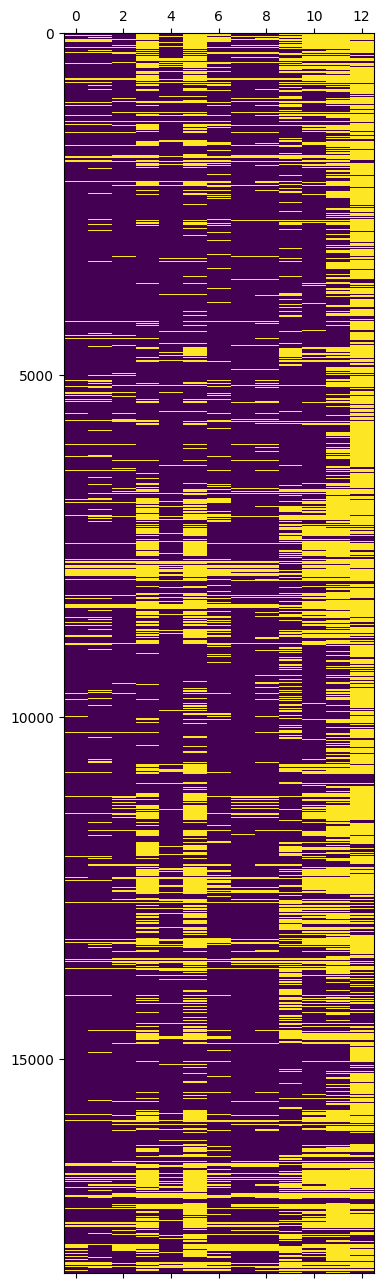

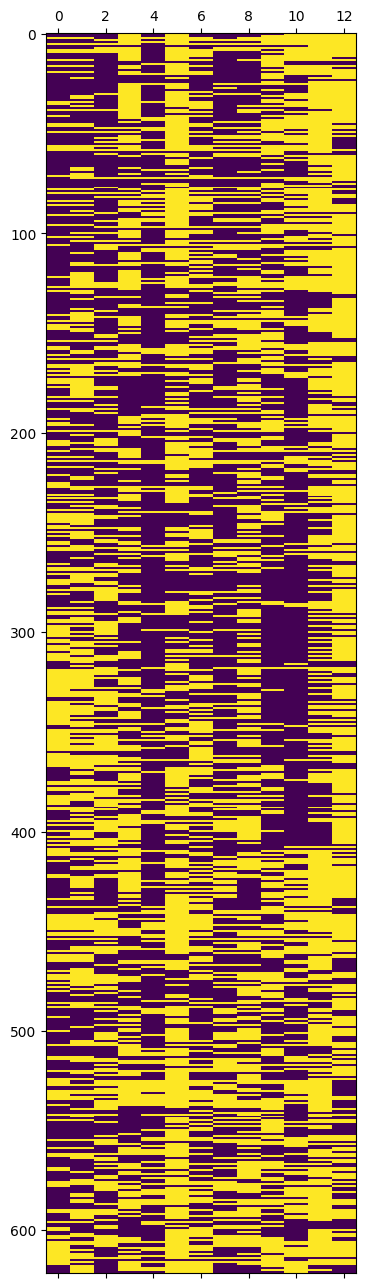

In [350]:
import matplotlib.pyplot as plt

p1 = plt.matshow(pivot_full, cmap="viridis", aspect="auto")
p2 = plt.matshow(pivot_full_no_duplicates, cmap="viridis", aspect="auto")

In [355]:
save_dir = (
    "/Users/sijianfan/Documents/projects/BiSSGL/datasets/realAnalysis/tuberculosis"
)
os.makedirs(f"{save_dir}", exist_ok=True)
filename = "strains_vs_drugs.csv"
pivot_full_no_duplicates.to_csv(f"{save_dir}/{filename}", index=True)

In [31]:
filename = "strains_vs_drugs_all.csv"
pivot_full.to_csv(f"{save_dir}/{filename}", index=True)

---

### 3. Strain mutation information

Here we try to use SNPs as mutation gene markers

In [ ]:
print(strains[["Strain", "Genome ID", "Assembly Accession", "SRA Accession"]].head(20))

          Strain     Genome ID Assembly Accession SRA Accession
0      CECT 3035  1.041522e+06    GCA_000222105.4     SRR231104
1    INCQS 00594  1.087469e+06    GCF_000363915.2           NaN
2    INCQS 00594  1.087469e+06    GCA_000363915.2           NaN
3       CTRI-134  1.105055e+05    GCF_001881585.1           NaN
4   NLA000701671  1.158622e+05                NaN           NaN
5    NLA00020191  1.158622e+05    GCA_013366335.1           NaN
6   NLA000201913  1.158623e+05    GCA_014489215.1           NaN
7         300103  1.158624e+05                NaN           NaN
8     strain M18  1.162284e+06    GCA_000261085.1           NaN
9        3563-15  1.185650e+06    GCA_015499805.1           NaN
10       8844-15  1.185650e+06    GCA_015499835.1           NaN
11       4549-15  1.185650e+06    GCA_015499845.1           NaN
12      11351-15  1.185650e+06    GCA_015499865.1           NaN
13          GD17  1.185650e+06    GCA_017183835.1           NaN
14       2572-15  1.185651e+06    GCA_01

In [ ]:
# pivot 的 index 是最终挑选的 strain
final_strains = pivot_full.index.tolist()
print("Final strain count:", len(final_strains))

# 从 strains 表中过滤 strain + assembly
strains_sub = strains[strains["Strain"].isin(final_strains)].copy()
print("Matched strains:", strains_sub.shape)

# 只保留有可用 assembly 的行
strains_sub = strains_sub.dropna(subset=["Assembly Accession"])
print("Strains with assemblies:", strains_sub.shape)

# 最终我们需要 Strain 和 Assembly Accession
mut_input = strains_sub[["Strain", "Assembly Accession"]].drop_duplicates()
print(mut_input.head(10))
print("Total assemblies available:", mut_input.shape[0])
print("Total unique strains:", mut_input.nunique()[0])

Final strain count: 18132
Matched strains: (19516, 90)
Strains with assemblies: (8151, 90)
           Strain Assembly Accession
5     NLA00020191    GCA_013366335.1
6    NLA000201913    GCA_014489215.1
17       NA-A0008    GCA_000296175.1
18       NA-A0009    GCA_000296155.1
24  UM 1072388579    GCA_000313215.2
25              K    GCA_000698475.1
26       PanR0201    GCA_000442945.1
27       PanR0802    GCA_000442965.1
28       PanR1005    GCA_000443005.1
29       PanR0704    GCA_000442795.1
Total assemblies available: 7932
Total unique strains: 6949


In [ ]:
mut_input.groupby("Strain").size()

Strain
00-10219    1
00-15489    1
00-R0023    1
00-R0025    1
00-R0086    1
           ..
sz6213      1
sz9610      1
wh18        1
wx2         1
wx6         1
Length: 6949, dtype: int64

In [404]:
filename = "strains_assembly_list.csv"
mut_input.to_csv(f"{save_dir}/{filename}", index=False)

In [405]:
df = mut_input.copy()

In [ ]:
# 清洗 assembly 字符串（去空格）
df["assembly_acc"] = df["Assembly Accession"].astype(str).str.strip()
# 仅保留以 GCA_ 或 GCF_ 开头的
df = df[df["assembly_acc"].str.match(r"^(GCA_|GCF_)", na=False)].copy()
print("After filter GCA/GCF rows:", len(df))

# 抽取 10 个测试样本（若少于10就全部）
test_n = min(10, len(df))
test_df = df.drop_duplicates(subset=["assembly_acc"]).head(test_n)
test_df.to_csv(f"{save_dir}/test_assemblies_10.csv", index=False)
print("Wrote test_assemblies_10.csv")
print(test_df)

After filter GCA/GCF rows: 7932
Wrote test_assemblies_10.csv
           Strain Assembly Accession     assembly_acc
5     NLA00020191    GCA_013366335.1  GCA_013366335.1
6    NLA000201913    GCA_014489215.1  GCA_014489215.1
17       NA-A0008    GCA_000296175.1  GCA_000296175.1
18       NA-A0009    GCA_000296155.1  GCA_000296155.1
24  UM 1072388579    GCA_000313215.2  GCA_000313215.2
25              K    GCA_000698475.1  GCA_000698475.1
26       PanR0201    GCA_000442945.1  GCA_000442945.1
27       PanR0802    GCA_000442965.1  GCA_000442965.1
28       PanR1005    GCA_000443005.1  GCA_000443005.1
29       PanR0704    GCA_000442795.1  GCA_000442795.1


In [ ]:
# 测试成功后对整体处理
df["assembly_acc"] = df["Assembly Accession"].astype(str).str.strip()

df = df[df["assembly_acc"].str.match(r"^(GCA_|GCF_)", na=False)].copy()
print("After filter GCA/GCF rows:", len(df))

all_df = df.drop_duplicates(subset=["assembly_acc"])
all_df.to_csv(f"{save_dir}/all_assemblies.csv", index=False)
print("Wrote all_assemblies.csv")

After filter GCA/GCF rows: 7932
Wrote all_assemblies.csv


In [ ]:
temp = pd.read_table(f"{save_dir}/all_accs.txt", header=None, names=["assembly_acc"])

In [418]:
temp

,assembly_acc
0,GCA_013366335.1
1,GCA_014489215.1
2,GCA_000296175.1
3,GCA_000296155.1
4,GCA_000313215.2
...,...
7927,GCF_000831245.1
7928,GCA_003266045.1
7929,GCA_000220415.1
7930,GCA_000220435.1


In [ ]:
temp.index[temp["assembly_acc"] == "GCA_002131325.1"].tolist()

[7560]